In [136]:
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import seaborn as sns
import os
import glob
from datetime import datetime
from datetime import timedelta
from matplotlib import pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
from matplotlib import cm
import matplotlib.dates as mdates
from scipy.interpolate import interp2d
warnings.filterwarnings('ignore')
#import datetime
import scipy.ndimage as ndimage
from matplotlib import cm
import geopy.distance
#import matplotlib as mpl
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import leafmap
import plotly.express as px
import matplotlib as mpl
import xarray as xr
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import math
#import pysplit
import netCDF4
import xarray as xr
import re

In [137]:
def simple_read(path):
    with open(path) as f:
        first_line = f.readline()
        header_line = int(first_line[0:-2].split(",")[0]) - 1
    data = pd.read_csv(path, sep=',', skiprows=header_line)
    data.columns = [i.strip() for i in data.columns]

    acc = 0
    boo = False
    for letter in path:
        if letter == '2':
            boo = True
        elif boo and letter == '0':
            acc -= 1
            break
        acc += 1
    dt = datetime(int(path[acc:acc+4]), int(path[acc+4:acc+6]), int(path[acc+6:acc+8]))

    for column in data.columns:
        if 'Time' in column:
            data[column] = dt + pd.to_timedelta(data[column], unit='seconds')

    return data.replace([-999999, -66666, -9999, -99999], np.NaN)

# Read all .ict files
file_paths = glob.glob("C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/merge/*.ict")

# Read and combine all valid files
dfs = []
for path in file_paths:
    try:
        df = simple_read(path)
        if not df.empty:
            dfs.append(df)
    except Exception as e:
        print(f"Failed to read {path}: {e}")

# Concatenate all data
if dfs:
    all_data = pd.concat(dfs, ignore_index=True)
    print("Concatenated DataFrame shape:", all_data.shape)
else:
    print("No valid .ict files to concatenate.")

all_data


Concatenated DataFrame shape: (34389, 61)


,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,...,SMPS_Bin21_ZIEMBA,SMPS_Bin22_ZIEMBA,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA
0,2020-02-14 17:02:30,2020-02-14 17:03:30,37.107117,-76.271678,928.0639,661.4223,712.2982,746.2097,978.2278,809.7720,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-14 17:03:30,2020-02-14 17:04:30,37.117686,-76.187906,1436.0700,508.8857,632.0458,645.7263,912.6558,767.9438,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-14 17:04:30,2020-02-14 17:05:30,37.104690,-76.095953,1660.7700,390.8450,454.3137,498.9765,667.5678,604.0493,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-14 17:05:30,2020-02-14 17:06:30,37.089665,-76.005278,1717.1000,423.5440,519.6313,583.7020,808.9588,685.6930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-14 17:06:30,2020-02-14 17:07:30,37.073995,-75.912586,1713.4100,434.1577,521.2490,584.6930,725.2003,676.9852,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34384,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,6907.1700,5660.1800,4806.3500,4283.7200,4145.8400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34385,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,7740.5200,6235.0500,5267.8200,4396.5500,4129.3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34386,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34387,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [138]:
def read_las_file(path):
    try:
        # Detect where the actual header starts (after last line with only "*")
        with open(path, 'r') as f:
            lines = f.readlines()
            for i in reversed(range(len(lines))):
                if lines[i].strip().startswith('***'):
                    data_start = i + 1
                    break
            else:
                raise ValueError("No header delimiter (*****) found.")

        # Extract date from filename
        date_match = re.search(r'(\d{4})(\d{2})(\d{2})', os.path.basename(path))
        if not date_match:
            raise ValueError("Date not found in filename")
        base_date = datetime(*map(int, date_match.groups()))

        # Read CSV data
        df = pd.read_csv(path, skiprows=data_start)
        df.columns = [col.strip() for col in df.columns]

        # Convert time columns to datetime, preserving original column names
        for col in df.columns:
            if col.lower().startswith("time_") or "time" in col.lower():
                df[col] = pd.to_numeric(df[col], errors='coerce')
                df[col] = df[col].apply(lambda x: base_date + timedelta(seconds=int(x)) if pd.notna(x) else pd.NaT)

        # Replace invalid values with NA
        df.replace([-9999, -8888, -7777, -9999.000], pd.NA, inplace=True)

        return df

    except Exception as e:
        print(f"⚠️ Error reading {path}:\n{e}")
        return None

def process_las_directory(folder_path):
    all_data = []
    paths = glob.glob(os.path.join(folder_path, '**/*.ict'), recursive=True)
    for path in paths:
        df = read_las_file(path)
        if df is not None:
            all_data.append(df)
    if not all_data:
        raise ValueError("❌ No valid LAS files processed.")
    return pd.concat(all_data, ignore_index=True)

# Usage example:
# df = process_las_directory("C:/your/LAS/folder")


In [139]:
folder = 'C:/Users/taiwoajayi/OneDrive - University of Arizona/ACTIVATE_PROJ_NEW/2022'
Leg = process_las_directory(folder)
Leg

,Time_Start,Time_Stop,Julian_Day,Date,LegIndex
0,2020-02-14 17:01:23,2020-02-14 17:04:58,45,20200214,1001110000
1,2020-02-14 17:05:03,2020-02-14 17:16:17,45,20200214,1001110001
2,2020-02-14 17:16:17,2020-02-14 17:18:51,45,20200214,1001110008
3,2020-02-14 17:19:21,2020-02-14 17:22:51,45,20200214,1001110102
4,2020-02-14 17:24:00,2020-02-14 17:27:57,45,20200214,1001110103
...,...,...,...,...,...
7400,2022-06-18 14:57:37,2022-06-18 15:01:20,22169,20220618,6179100113
7401,2022-06-18 15:03:08,2022-06-18 15:05:43,22169,20220618,6179100113
7402,2022-06-18 15:12:00,2022-06-18 15:14:46,22169,20220618,6179100106
7403,2022-06-18 15:16:27,2022-06-18 15:19:34,22169,20220618,6179100001


In [140]:
def match_and_fill_Leg_to_all_data(Leg, all_data, columns_to_add):
    """
    Matches `Time_Start` from `Leg` to `all_data`, forward-filling only until the next available timestamp.
    """
    Leg["Time_Start"] = pd.to_datetime(Leg["Time_Start"])
    all_data["Time_Start"] = pd.to_datetime(all_data["Time_Start"])

    Leg.sort_values("Time_Start", inplace=True)
    all_data.sort_values("Time_Start", inplace=True)

    # ✅ Remove duplicate timestamps from Leg to allow reindexing
    Leg = Leg.drop_duplicates(subset="Time_Start", keep="first")

    Leg = Leg.set_index("Time_Start")
    all_data = all_data.set_index("Time_Start")

    all_data[columns_to_add] = Leg[columns_to_add].reindex(all_data.index, method="ffill")

    all_data.reset_index(inplace=True)
    return all_data

# Example usage:
columns_to_add = ['Julian_Day',	'LegIndex']  # Replace with actual column names

all_data_filled = match_and_fill_Leg_to_all_data(Leg, all_data, columns_to_add)

# ✅ Check if Time_Start has NaT
print(f"Number of NaT values in `Time_Start`: {all_data_filled['Time_Start'].isna().sum()}")


Number of NaT values in `Time_Start`: 0


In [141]:
all_data_filled

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,...,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA,Julian_Day,LegIndex
0,2020-02-14 17:02:30,2020-02-14 17:03:30,37.107117,-76.271678,928.0639,661.4223,712.2982,746.2097,978.2278,809.7720,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,1001110000
1,2020-02-14 17:03:30,2020-02-14 17:04:30,37.117686,-76.187906,1436.0700,508.8857,632.0458,645.7263,912.6558,767.9438,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,1001110000
2,2020-02-14 17:04:30,2020-02-14 17:05:30,37.104690,-76.095953,1660.7700,390.8450,454.3137,498.9765,667.5678,604.0493,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,1001110000
3,2020-02-14 17:05:30,2020-02-14 17:06:30,37.089665,-76.005278,1717.1000,423.5440,519.6313,583.7020,808.9588,685.6930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,1001110001
4,2020-02-14 17:06:30,2020-02-14 17:07:30,37.073995,-75.912586,1713.4100,434.1577,521.2490,584.6930,725.2003,676.9852,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,1001110001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34384,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,6907.1700,5660.1800,4806.3500,4283.7200,4145.8400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,6179100001
34385,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,7740.5200,6235.0500,5267.8200,4396.5500,4129.3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,6179100000
34386,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,6179100000
34387,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,6179100000


In [142]:
list(all_data_filled.columns)

['Time_Start',
 'Time_Stop',
 'Latitude_THORNHILL',
 'Longitude_THORNHILL',
 'GPS_Altitude_THORNHILL',
 'LAS_Bin01_ZIEMBA',
 'LAS_Bin02_ZIEMBA',
 'LAS_Bin03_ZIEMBA',
 'LAS_Bin04_ZIEMBA',
 'LAS_Bin05_ZIEMBA',
 'LAS_Bin06_ZIEMBA',
 'LAS_Bin07_ZIEMBA',
 'LAS_Bin08_ZIEMBA',
 'LAS_Bin09_ZIEMBA',
 'LAS_Bin10_ZIEMBA',
 'LAS_Bin11_ZIEMBA',
 'LAS_Bin12_ZIEMBA',
 'LAS_Bin13_ZIEMBA',
 'LAS_Bin14_ZIEMBA',
 'LAS_Bin15_ZIEMBA',
 'LAS_Bin16_ZIEMBA',
 'LAS_Bin17_ZIEMBA',
 'LAS_Bin18_ZIEMBA',
 'LAS_Bin19_ZIEMBA',
 'LAS_Bin20_ZIEMBA',
 'LAS_Bin21_ZIEMBA',
 'LAS_Bin22_ZIEMBA',
 'LAS_Bin23_ZIEMBA',
 'LAS_Bin24_ZIEMBA',
 'LAS_Bin25_ZIEMBA',
 'LAS_Bin26_ZIEMBA',
 'SMPS_Bin01_ZIEMBA',
 'SMPS_Bin02_ZIEMBA',
 'SMPS_Bin03_ZIEMBA',
 'SMPS_Bin04_ZIEMBA',
 'SMPS_Bin05_ZIEMBA',
 'SMPS_Bin06_ZIEMBA',
 'SMPS_Bin07_ZIEMBA',
 'SMPS_Bin08_ZIEMBA',
 'SMPS_Bin09_ZIEMBA',
 'SMPS_Bin10_ZIEMBA',
 'SMPS_Bin11_ZIEMBA',
 'SMPS_Bin12_ZIEMBA',
 'SMPS_Bin13_ZIEMBA',
 'SMPS_Bin14_ZIEMBA',
 'SMPS_Bin15_ZIEMBA',
 'SMPS_Bin16_ZIEMBA',

In [143]:
all_data_filled["LegIndex"] = all_data_filled["LegIndex"].apply(lambda x: str(x)[-2:] if pd.notna(x) else pd.NA)
all_data_filled["LegIndex"]


0        00
1        00
2        00
3        01
4        01
         ..
34384    01
34385    00
34386    00
34387    00
34388    00
Name: LegIndex, Length: 34389, dtype: object

In [144]:
# Step 1: Create a helper function to find valid rows for each date
def get_valid_indices_by_leg(df):
    valid_indices = []
    for day, group in df.groupby(df["Time_Start"].dt.date):
        group_sorted = group.sort_values("Time_Start")
        drop_until = 0
        for i, val in enumerate(group_sorted["LegIndex"]):
            if val in {"00", "01", "08"}:
                drop_until = i + 1
            else:
                break
        valid_indices.extend(group_sorted.index[drop_until:])
    return valid_indices

valid_indices = get_valid_indices_by_leg(all_data_filled)
all_filtered = all_data_filled.loc[valid_indices].copy()
all_filtered


,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,...,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA,Julian_Day,LegIndex
17,2020-02-14 17:19:30,2020-02-14 17:20:30,36.921090,-74.752218,749.5914,681.6613,705.1017,756.0542,1016.10,899.1187,...,1648.75,1254.34,1358.52,1439.64,1157.8600,1125.10,971.96,766.3200,45,02
18,2020-02-14 17:20:30,2020-02-14 17:21:30,36.923567,-74.675343,741.0926,746.9983,778.0290,846.4772,1104.24,935.1700,...,1728.52,1316.56,1048.73,1223.78,983.6053,1101.78,1068.51,819.1298,45,02
19,2020-02-14 17:21:30,2020-02-14 17:22:30,36.925131,-74.594640,737.8327,699.0663,840.3403,930.7470,1200.44,1024.8300,...,1811.91,1381.60,724.85,998.10,801.4300,1077.40,1169.44,874.3400,45,02
20,2020-02-14 17:22:30,2020-02-14 17:23:30,36.925710,-74.512400,818.7221,771.4782,868.3347,913.9722,1127.81,991.1935,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,02
21,2020-02-14 17:23:30,2020-02-14 17:24:30,36.923070,-74.431485,997.8222,774.0317,860.7362,941.8255,1299.45,992.6628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34384,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,6907.1700,5660.1800,4806.3500,4283.72,4145.8400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,01
34385,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,7740.5200,6235.0500,5267.8200,4396.55,4129.3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,00
34386,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,00
34387,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,00


In [145]:
# List of dates to remove
dates_to_remove = [
    "2020-08-17", "2020-08-21", "2020-09-02", "2020-09-10", "2020-09-11", "2020-09-29",
    "2021-03-23", "2021-05-15", "2021-05-18", "2021-05-21", "2021-06-02", "2021-06-07",
    "2021-06-08", "2021-06-26", "2021-06-28", "2021-06-29", "2021-06-30", "2022-02-02",
    "2022-02-03", "2022-03-07", "2022-05-10", "2022-05-16", "2022-06-07", "2022-06-08"
]

# Convert Time_Start column to datetime format
all_filtered['Time_Start'] = pd.to_datetime(all_filtered['Time_Start'])

# Filter out the rows with the specified dates
combined_dff = all_filtered[~all_filtered['Time_Start'].dt.strftime('%Y-%m-%d').isin(dates_to_remove)]

combined_dff


,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,...,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA,Julian_Day,LegIndex
17,2020-02-14 17:19:30,2020-02-14 17:20:30,36.921090,-74.752218,749.5914,681.6613,705.1017,756.0542,1016.10,899.1187,...,1648.75,1254.34,1358.52,1439.64,1157.8600,1125.10,971.96,766.3200,45,02
18,2020-02-14 17:20:30,2020-02-14 17:21:30,36.923567,-74.675343,741.0926,746.9983,778.0290,846.4772,1104.24,935.1700,...,1728.52,1316.56,1048.73,1223.78,983.6053,1101.78,1068.51,819.1298,45,02
19,2020-02-14 17:21:30,2020-02-14 17:22:30,36.925131,-74.594640,737.8327,699.0663,840.3403,930.7470,1200.44,1024.8300,...,1811.91,1381.60,724.85,998.10,801.4300,1077.40,1169.44,874.3400,45,02
20,2020-02-14 17:22:30,2020-02-14 17:23:30,36.925710,-74.512400,818.7221,771.4782,868.3347,913.9722,1127.81,991.1935,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,02
21,2020-02-14 17:23:30,2020-02-14 17:24:30,36.923070,-74.431485,997.8222,774.0317,860.7362,941.8255,1299.45,992.6628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34384,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,6907.1700,5660.1800,4806.3500,4283.72,4145.8400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,01
34385,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,7740.5200,6235.0500,5267.8200,4396.55,4129.3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,00
34386,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,00
34387,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,00


In [146]:
D202 = combined_dff[combined_dff["GPS_Altitude_THORNHILL"] < 2000].copy()
D202

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,...,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA,Julian_Day,LegIndex
17,2020-02-14 17:19:30,2020-02-14 17:20:30,36.921090,-74.752218,749.5914,681.6613,705.1017,756.0542,1016.10,899.1187,...,1648.75,1254.34,1358.52,1439.64,1157.8600,1125.10,971.96,766.3200,45,02
18,2020-02-14 17:20:30,2020-02-14 17:21:30,36.923567,-74.675343,741.0926,746.9983,778.0290,846.4772,1104.24,935.1700,...,1728.52,1316.56,1048.73,1223.78,983.6053,1101.78,1068.51,819.1298,45,02
19,2020-02-14 17:21:30,2020-02-14 17:22:30,36.925131,-74.594640,737.8327,699.0663,840.3403,930.7470,1200.44,1024.8300,...,1811.91,1381.60,724.85,998.10,801.4300,1077.40,1169.44,874.3400,45,02
20,2020-02-14 17:22:30,2020-02-14 17:23:30,36.925710,-74.512400,818.7221,771.4782,868.3347,913.9722,1127.81,991.1935,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,02
21,2020-02-14 17:23:30,2020-02-14 17:24:30,36.923070,-74.431485,997.8222,774.0317,860.7362,941.8255,1299.45,992.6628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34384,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,6907.1700,5660.1800,4806.3500,4283.72,4145.8400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,01
34385,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,7740.5200,6235.0500,5267.8200,4396.55,4129.3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,00
34386,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,00
34387,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22169,00


In [147]:
LAS_mid = [100.0, 112.2, 125.9, 141.3, 158.5, 177.8, 199.5, 223.9, 251.2, 281.8, 316.2, 354.8, 398.1, 446.7, 501.2, 562.3, 631.0, 707.9, 794.3, 891.3, 1000.0, 1258.9, 1584.9, 1995.3, 2511.9, 3162.3]
SMPS_mid = [3.16, 3.55, 3.98, 4.47, 5.01, 5.62, 6.31, 7.08, 7.94, 8.91, 10.0, 11.2, 12.6, 14.1, 15.8, 17.8, 20.0, 22.4, 25.1, 28.2, 31.6, 35.5, 39.8, 44.7, 50.1, 56.2, 63.1, 70.8, 79.4, 89.1]
all_mid =  SMPS_mid + LAS_mid
all_mid_val = pd.DataFrame(all_mid, columns=['value'])
all_mid_val

,value
0,3.16
1,3.55
2,3.98
3,4.47
4,5.01
5,5.62
6,6.31
7,7.08
8,7.94
9,8.91


In [148]:
# Columns to remove
columns_to_remove = ['Julian_Day',	'LegIndex']

# Remove the specified columns in-place
D202.drop(columns=columns_to_remove, inplace=True)
D202

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,...,SMPS_Bin21_ZIEMBA,SMPS_Bin22_ZIEMBA,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA
17,2020-02-14 17:19:30,2020-02-14 17:20:30,36.921090,-74.752218,749.5914,681.6613,705.1017,756.0542,1016.10,899.1187,...,2671.40,2081.66,1648.75,1254.34,1358.52,1439.64,1157.8600,1125.10,971.96,766.3200
18,2020-02-14 17:20:30,2020-02-14 17:21:30,36.923567,-74.675343,741.0926,746.9983,778.0290,846.4772,1104.24,935.1700,...,1988.78,1948.34,1728.52,1316.56,1048.73,1223.78,983.6053,1101.78,1068.51,819.1298
19,2020-02-14 17:21:30,2020-02-14 17:22:30,36.925131,-74.594640,737.8327,699.0663,840.3403,930.7470,1200.44,1024.8300,...,1275.13,1808.95,1811.91,1381.60,724.85,998.10,801.4300,1077.40,1169.44,874.3400
20,2020-02-14 17:22:30,2020-02-14 17:23:30,36.925710,-74.512400,818.7221,771.4782,868.3347,913.9722,1127.81,991.1935,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,2020-02-14 17:23:30,2020-02-14 17:24:30,36.923070,-74.431485,997.8222,774.0317,860.7362,941.8255,1299.45,992.6628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34384,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,6907.1700,5660.1800,4806.3500,4283.72,4145.8400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34385,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,7740.5200,6235.0500,5267.8200,4396.55,4129.3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34386,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34387,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [149]:
# Define the latitude and longitude range
latitude_start = 37.095692
longitude_start = -76.322753
latitude_end = 36.938 #36.88
longitude_end = -72.666

# Filter the data based on the latitude and longitude range
Zibut = D202[
    (D202['Latitude_THORNHILL'] <= latitude_start) &
    (D202['Latitude_THORNHILL'] >= latitude_end) &
    (D202['Longitude_THORNHILL'] >= longitude_start) &
    (D202['Longitude_THORNHILL'] <= longitude_end)
]

# Display the filtered data
Zibut

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,...,SMPS_Bin21_ZIEMBA,SMPS_Bin22_ZIEMBA,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA
42,2020-02-14 17:44:30,2020-02-14 17:45:30,36.940768,-72.705473,1571.6300,483.7165,519.4037,524.6192,648.8803,553.8532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,2020-02-14 19:09:30,2020-02-14 19:10:30,36.938021,-72.710364,1862.4100,476.0877,606.1637,648.6118,728.3707,658.7917,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,2020-02-14 19:10:30,2020-02-14 19:11:30,36.938742,-72.778119,1854.1400,489.6943,565.0530,654.5133,760.8545,708.6625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,2020-02-14 19:11:30,2020-02-14 19:12:30,36.938801,-72.848010,1660.2200,449.2657,592.7117,734.0703,975.2435,796.5487,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,2020-02-14 19:12:30,2020-02-14 19:13:30,36.938202,-72.921176,1499.2000,796.2988,1252.3300,1702.5600,2191.5600,1936.6300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34347,2022-06-18 14:42:30,2022-06-18 14:43:30,36.939159,-72.848719,1881.0900,6236.6500,5503.9200,4740.7900,3810.3500,3343.6200,...,2685.17,3435.34,3910.74,3850.77,3434.14,4002.24,4452.90,4017.59,2095.66,0.0
34350,2022-06-18 14:45:30,2022-06-18 14:46:30,36.938114,-73.123534,183.0150,5470.0600,4224.8800,3707.5000,3544.1900,3254.9200,...,4008.43,5351.99,6549.51,6357.64,5855.00,6312.64,4846.93,2611.23,0.00,0.0
34351,2022-06-18 14:46:30,2022-06-18 14:47:30,36.938584,-73.212561,118.1848,5564.8400,4326.6700,3648.7400,3382.3900,3193.4000,...,3497.78,4797.66,5405.23,5850.44,5048.72,7493.15,5227.59,2328.32,0.00,0.0
34352,2022-06-18 14:47:30,2022-06-18 14:48:30,36.938774,-73.300997,119.2150,5570.7800,4354.8900,3652.1800,3284.1700,3087.1800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [150]:
# Define the main latitude and longitude range for Oxana
latitude_start = 37.095692
longitude_start = -76.322753
latitude_end = 34.363
longitude_end = -73.759

# Filter Oxana to include only the main diagonal flight path
Oxana = D202[
    (D202['Latitude_THORNHILL'] <= latitude_start) &
    (D202['Latitude_THORNHILL'] >= latitude_end) &
    (D202['Longitude_THORNHILL'] >= longitude_start) &
    (D202['Longitude_THORNHILL'] <= longitude_end)
]

# Define specific exclusion zones (red regions)
# Zone 1: Upper horizontal region
zone_1 = (
    (Oxana['Latitude_THORNHILL'] > 36.5) &
    (Oxana['Latitude_THORNHILL'] < 37.2) &
    (Oxana['Longitude_THORNHILL'] > -75.5) &
    (Oxana['Longitude_THORNHILL'] < -74.0)
)

# Zone 2: Middle curve region
zone_2 = (
    (Oxana['Latitude_THORNHILL'] > 36.0) &
    (Oxana['Latitude_THORNHILL'] < 36.5) &
    (Oxana['Longitude_THORNHILL'] > -75.0) &
    (Oxana['Longitude_THORNHILL'] < -74.2)
)

# Zone 3: Top-left region (corrected)
zone_3 = (
    (Oxana['Latitude_THORNHILL'] > 36.9) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 37.15) &
    (Oxana['Longitude_THORNHILL'] > -76.5) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -75.0)
)

zone_4 = (
    (Oxana['Latitude_THORNHILL'] > 36.0) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 37.2) &
    (Oxana['Longitude_THORNHILL'] > -74.5) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -73.0)
)

zone_5 = (
    (Oxana['Latitude_THORNHILL'] > 36.1) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 36.9) &
    (Oxana['Longitude_THORNHILL'] > -75.8) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -75.5)
)

'''zone_6 = (
    (Oxana['Latitude_THORNHILL'] > 34.0) &  # Refined latitude range
    (Oxana['Latitude_THORNHILL'] < 34.8) &
    (Oxana['Longitude_THORNHILL'] > -75) &  # Narrower longitude range
    (Oxana['Longitude_THORNHILL'] < -74.5)
)

zone_7 = (
    (Oxana['Latitude_THORNHILL'] > 35) &
    (Oxana['Latitude_THORNHILL'] < 35.8) &
    (Oxana['Longitude_THORNHILL'] > -74.05) &
    (Oxana['Longitude_THORNHILL'] < -73.5)
)

zone_8 = (
    (Oxana['Latitude_THORNHILL'] > 35.4) &
    (Oxana['Latitude_THORNHILL'] < 36.5) &
    (Oxana['Longitude_THORNHILL'] > -75) &
    (Oxana['Longitude_THORNHILL'] < -74.7)
)


zone_9 = (
    (Oxana['Latitude_THORNHILL'] > 36) &
    (Oxana['Latitude_THORNHILL'] < 36.5) &
    (Oxana['Longitude_THORNHILL'] > -75.1) &
    (Oxana['Longitude_THORNHILL'] < -75)
)


zone_10 = (
    (Oxana['Latitude_THORNHILL'] > 36.3) &
    (Oxana['Latitude_THORNHILL'] < 37) &
    (Oxana['Longitude_THORNHILL'] > -76) &
    (Oxana['Longitude_THORNHILL'] < -75.7)
)'''

# Combine exclusion zones
red_region = zone_1 | zone_2 | zone_3 | zone_4 | zone_5 #| zone_6 | zone_7 | zone_8 | zone_9 | zone_10

# Exclude points in the red regions
Oxana_filtered = Oxana[~red_region].copy()
Oxana_filtered


,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,...,SMPS_Bin21_ZIEMBA,SMPS_Bin22_ZIEMBA,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA
201,2020-02-15 17:07:30,2020-02-15 17:08:30,36.362198,-76.109521,892.7367,1160.3200,1372.0800,1376.1600,1210.4400,529.1815,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
202,2020-02-15 17:08:30,2020-02-15 17:09:30,36.311238,-76.062582,892.4134,1007.9600,1396.1800,1425.2000,1213.5800,485.8740,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203,2020-02-15 17:09:30,2020-02-15 17:10:30,36.259224,-76.015465,891.1887,1039.0500,1490.4600,1535.1600,1279.5700,559.4032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
204,2020-02-15 17:10:30,2020-02-15 17:11:30,36.207892,-75.968825,987.3515,1388.9800,1840.8000,1664.9700,1401.0300,643.3895,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
205,2020-02-15 17:11:30,2020-02-15 17:12:30,36.158192,-75.923650,1057.3600,926.7422,935.5157,694.1247,608.7088,233.7438,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34384,2022-06-18 15:19:30,2022-06-18 15:20:30,36.893359,-76.070696,666.2548,6907.1700,5660.1800,4806.3500,4283.7200,4145.8400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34385,2022-06-18 15:20:30,2022-06-18 15:21:30,36.874850,-76.138263,481.7979,7740.5200,6235.0500,5267.8200,4396.5500,4129.3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34386,2022-06-18 15:21:30,2022-06-18 15:22:30,36.854486,-76.190263,306.1552,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34387,2022-06-18 15:22:30,2022-06-18 15:23:30,36.872941,-76.214895,89.5975,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [151]:
# List of dates to remove
dates_to_remove = [
    "2020-03-11", "2020-08-20", "2021-05-19", "2021-06-05", "2021-06-24", "2022-02-22", "2022-05-05", "2022-05-21"
]

# Convert Time_Start column to datetime format
Oxana_filtered['Time_Start'] = pd.to_datetime(Oxana_filtered['Time_Start'])

# Filter out the rows with the specified dates
Oxana_filtered = Oxana_filtered[~Oxana_filtered['Time_Start'].dt.strftime('%Y-%m-%d').isin(dates_to_remove)]

print("Filtered DataFrame:")
print(Oxana_filtered)


Filtered DataFrame:
               Time_Start           Time_Stop  Latitude_THORNHILL  \
201   2020-02-15 17:07:30 2020-02-15 17:08:30           36.362198   
202   2020-02-15 17:08:30 2020-02-15 17:09:30           36.311238   
203   2020-02-15 17:09:30 2020-02-15 17:10:30           36.259224   
204   2020-02-15 17:10:30 2020-02-15 17:11:30           36.207892   
205   2020-02-15 17:11:30 2020-02-15 17:12:30           36.158192   
...                   ...                 ...                 ...   
34384 2022-06-18 15:19:30 2022-06-18 15:20:30           36.893359   
34385 2022-06-18 15:20:30 2022-06-18 15:21:30           36.874850   
34386 2022-06-18 15:21:30 2022-06-18 15:22:30           36.854486   
34387 2022-06-18 15:22:30 2022-06-18 15:23:30           36.872941   
34388 2022-06-18 15:23:30 2022-06-18 15:24:30           36.888076   

       Longitude_THORNHILL  GPS_Altitude_THORNHILL  LAS_Bin01_ZIEMBA  \
201             -76.109521                892.7367         1160.3200   
202    

In [152]:
OX = Oxana_filtered
OX
ZI = Zibut
ZI

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,...,SMPS_Bin21_ZIEMBA,SMPS_Bin22_ZIEMBA,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA
42,2020-02-14 17:44:30,2020-02-14 17:45:30,36.940768,-72.705473,1571.6300,483.7165,519.4037,524.6192,648.8803,553.8532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,2020-02-14 19:09:30,2020-02-14 19:10:30,36.938021,-72.710364,1862.4100,476.0877,606.1637,648.6118,728.3707,658.7917,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,2020-02-14 19:10:30,2020-02-14 19:11:30,36.938742,-72.778119,1854.1400,489.6943,565.0530,654.5133,760.8545,708.6625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,2020-02-14 19:11:30,2020-02-14 19:12:30,36.938801,-72.848010,1660.2200,449.2657,592.7117,734.0703,975.2435,796.5487,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,2020-02-14 19:12:30,2020-02-14 19:13:30,36.938202,-72.921176,1499.2000,796.2988,1252.3300,1702.5600,2191.5600,1936.6300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34347,2022-06-18 14:42:30,2022-06-18 14:43:30,36.939159,-72.848719,1881.0900,6236.6500,5503.9200,4740.7900,3810.3500,3343.6200,...,2685.17,3435.34,3910.74,3850.77,3434.14,4002.24,4452.90,4017.59,2095.66,0.0
34350,2022-06-18 14:45:30,2022-06-18 14:46:30,36.938114,-73.123534,183.0150,5470.0600,4224.8800,3707.5000,3544.1900,3254.9200,...,4008.43,5351.99,6549.51,6357.64,5855.00,6312.64,4846.93,2611.23,0.00,0.0
34351,2022-06-18 14:46:30,2022-06-18 14:47:30,36.938584,-73.212561,118.1848,5564.8400,4326.6700,3648.7400,3382.3900,3193.4000,...,3497.78,4797.66,5405.23,5850.44,5048.72,7493.15,5227.59,2328.32,0.00,0.0
34352,2022-06-18 14:47:30,2022-06-18 14:48:30,36.938774,-73.300997,119.2150,5570.7800,4354.8900,3652.1800,3284.1700,3087.1800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [153]:
# Select all columns from the first LAS bin to last SMPS bin
start_col = 'LAS_Bin01_ZIEMBA'
end_col = 'SMPS_Bin30_ZIEMBA'

# Get the list of columns between those two (inclusive)
bin_columns = OX.loc[:, start_col:end_col].columns

# Compute row-wise mean and store in a new column
OX["Mean_LAS_SMOS"] = OX[bin_columns].mean(axis=1)
OX

# Get the list of columns between those two (inclusive)
bin_columns = ZI.loc[:, start_col:end_col].columns

# Compute row-wise mean and store in a new column
ZI["Mean_LAS_SMOS"] = ZI[bin_columns].mean(axis=1)
ZI

,Time_Start,Time_Stop,Latitude_THORNHILL,Longitude_THORNHILL,GPS_Altitude_THORNHILL,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,...,SMPS_Bin22_ZIEMBA,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA,Mean_LAS_SMOS
42,2020-02-14 17:44:30,2020-02-14 17:45:30,36.940768,-72.705473,1571.6300,483.7165,519.4037,524.6192,648.8803,553.8532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167.492167
127,2020-02-14 19:09:30,2020-02-14 19:10:30,36.938021,-72.710364,1862.4100,476.0877,606.1637,648.6118,728.3707,658.7917,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,189.967902
128,2020-02-14 19:10:30,2020-02-14 19:11:30,36.938742,-72.778119,1854.1400,489.6943,565.0530,654.5133,760.8545,708.6625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,193.426479
129,2020-02-14 19:11:30,2020-02-14 19:12:30,36.938801,-72.848010,1660.2200,449.2657,592.7117,734.0703,975.2435,796.5487,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,220.582846
130,2020-02-14 19:12:30,2020-02-14 19:13:30,36.938202,-72.921176,1499.2000,796.2988,1252.3300,1702.5600,2191.5600,1936.6300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,520.442353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34347,2022-06-18 14:42:30,2022-06-18 14:43:30,36.939159,-72.848719,1881.0900,6236.6500,5503.9200,4740.7900,3810.3500,3343.6200,...,3435.34,3910.74,3850.77,3434.14,4002.24,4452.90,4017.59,2095.66,0.0,1278.166682
34350,2022-06-18 14:45:30,2022-06-18 14:46:30,36.938114,-73.123534,183.0150,5470.0600,4224.8800,3707.5000,3544.1900,3254.9200,...,5351.99,6549.51,6357.64,5855.00,6312.64,4846.93,2611.23,0.00,0.0,1383.771622
34351,2022-06-18 14:46:30,2022-06-18 14:47:30,36.938584,-73.212561,118.1848,5564.8400,4326.6700,3648.7400,3382.3900,3193.4000,...,4797.66,5405.23,5850.44,5048.72,7493.15,5227.59,2328.32,0.00,0.0,1297.540438
34352,2022-06-18 14:47:30,2022-06-18 14:48:30,36.938774,-73.300997,119.2150,5570.7800,4354.8900,3652.1800,3284.1700,3087.1800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,972.034329


In [154]:
def compute_weekday_mean_normalized(df, reference_df):
    """
    Computes the mean values for each variable based on Day of the Week across all years.
    Normalizes using the mean from the reference dataset.
    """

    # Define weekdays order for sorting
    weekdays_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    df = df.copy()
    df['Time_Start'] = pd.to_datetime(df['Time_Start'], errors="coerce")

    # Extract date components
    df['DayOfWeek'] = df['Time_Start'].dt.day_name()

    # ✅ Select numeric columns (exclude non-numeric ones)
    excluded_cols = ['Time_Start', 'Time_Stop', 'Latitude_THORNHILL', 'Longitude_THORNHILL', 'DayOfWeek', 
                     'GPS_Altitude_THORNHILL']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.difference(excluded_cols, sort=False)

    # ✅ Compute global mean from the reference dataset (Oxana + Zibut combined)
    global_mean = reference_df[numeric_cols].abs().mean()  # Taking absolute mean

    # ✅ Compute mean values for each DayOfWeek
    grouped_data = df.groupby(["DayOfWeek"])[numeric_cols].mean().reset_index()

    # ✅ Normalize using global mean
    #normalized_values = grouped_data[numeric_cols] / global_mean  # Normalization by mean
    normalized_values = grouped_data[numeric_cols].divide(global_mean, axis=1)

    # Convert back to DataFrame
    normalized_df = pd.DataFrame(normalized_values, columns=numeric_cols, index=grouped_data.index)
    normalized_df.insert(0, "DayOfWeek", grouped_data["DayOfWeek"])  # Keep DayOfWeek column

    # ✅ Initialize dictionary to store results: DayOfWeek → Variables
    aggregated_data = {}

    # Store results in dictionary
    for _, row in normalized_df.iterrows():
        day = row["DayOfWeek"]
        aggregated_data[day] = {col: row[col] for col in numeric_cols}

    # ✅ Ensure output is sorted by weekdays order
    aggregated_data = {day: aggregated_data.get(day, {}) for day in weekdays_order}

    return aggregated_data

# ✅ Combine Oxana & Zibut datasets to compute the overall mean for normalization
combined_reference_df = pd.concat([Oxana_filtered, Zibut])

# ✅ Example Usage (Normalize using combined reference dataset)
aggregated_data_air = compute_weekday_mean_normalized(OX, combined_reference_df)
aggregated_data_air_zi = compute_weekday_mean_normalized(ZI, combined_reference_df)

# ✅ Example Access (Normalized mean values for each day of the week)
print(aggregated_data_air)
print(aggregated_data_air_zi)


{'Monday': {'LAS_Bin01_ZIEMBA': 1.340248038375245, 'LAS_Bin02_ZIEMBA': 1.1978125360363574, 'LAS_Bin03_ZIEMBA': 1.090220714817963, 'LAS_Bin04_ZIEMBA': 1.0012033684296027, 'LAS_Bin05_ZIEMBA': 0.9625174806102396, 'LAS_Bin06_ZIEMBA': 0.9063413822659652, 'LAS_Bin07_ZIEMBA': 0.8736916872177704, 'LAS_Bin08_ZIEMBA': 0.8418437845525403, 'LAS_Bin09_ZIEMBA': 0.7943568183341977, 'LAS_Bin10_ZIEMBA': 0.7410328440419273, 'LAS_Bin11_ZIEMBA': 0.6587668506846855, 'LAS_Bin12_ZIEMBA': 0.6740365024694314, 'LAS_Bin13_ZIEMBA': 0.6290347696379976, 'LAS_Bin14_ZIEMBA': 0.5974982890258036, 'LAS_Bin15_ZIEMBA': 0.7428816168568917, 'LAS_Bin16_ZIEMBA': 0.7396956773417096, 'LAS_Bin17_ZIEMBA': 0.618037637733405, 'LAS_Bin18_ZIEMBA': 0.68358631121411, 'LAS_Bin19_ZIEMBA': 0.7026042869544099, 'LAS_Bin20_ZIEMBA': 0.6563510418205227, 'LAS_Bin21_ZIEMBA': 0.4973903786057755, 'LAS_Bin22_ZIEMBA': 0.389682307548171, 'LAS_Bin23_ZIEMBA': 0.5909643748834034, 'LAS_Bin24_ZIEMBA': 0.5388566669219959, 'LAS_Bin25_ZIEMBA': 0.484326166466

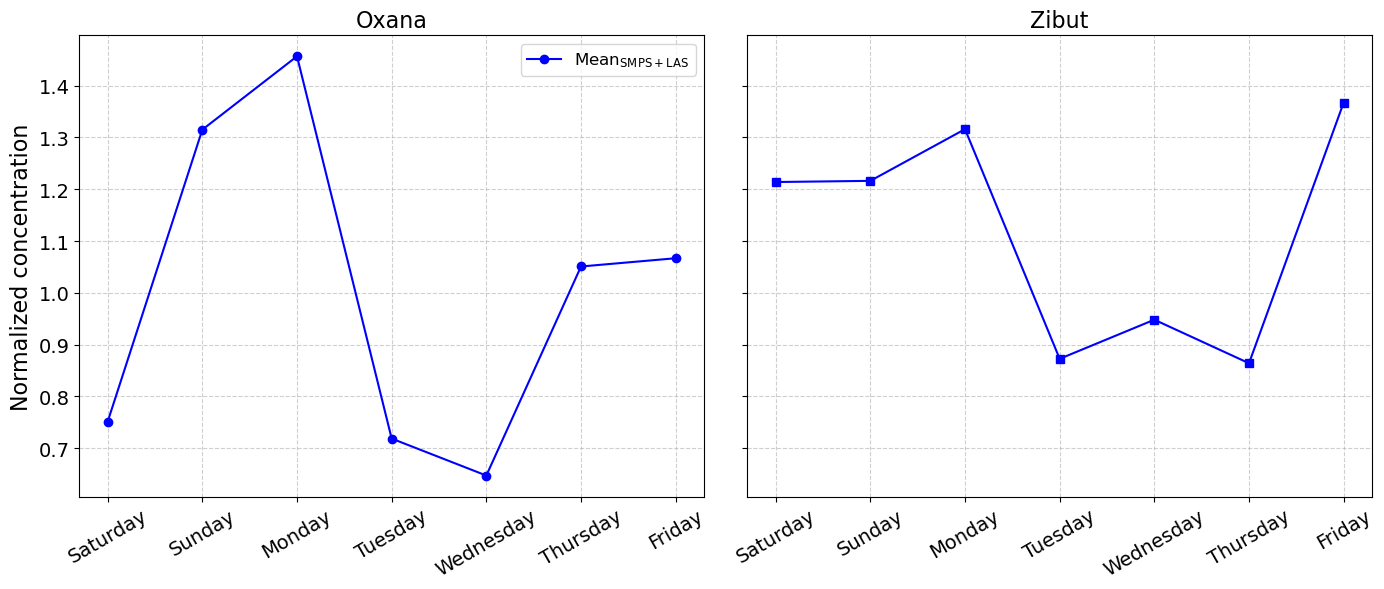

In [155]:
def plot_weekday_mean(aggregated_oxana, aggregated_zibut, variables, y_labels):
    """
    Plots the mean values for multiple variables across weekdays for Oxana and Zibut.
    Uses a 1x2 subplot layout (Oxana on left, Zibut on right).
    """

    weekdays_order = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

    # ✅ Create 1x2 subplot layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # Define colors for different variables
    colors = ["b", "r", "g", "orange", "purple", "brown"]

    # ✅ Plot for Oxana (Left Subplot)
    ax1 = axes[0]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        oxana_values = [aggregated_oxana.get(day, {}).get(variable, None) for day in weekdays_order]
        ax1.plot(weekdays_order, oxana_values, marker="o", linestyle="-", color=colors[i % len(colors)], label=y_label)

    ax1.set_title("Oxana", fontsize=16)
    ax1.set_ylabel("Normalized concentration", fontsize=16)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.tick_params(axis='both', labelsize=14)
    ax1.legend(fontsize=12)

    # ✅ Plot for Zibut (Right Subplot)
    ax2 = axes[1]
    for i, (variable, y_label) in enumerate(zip(variables, y_labels)):
        zibut_values = [aggregated_zibut.get(day, {}).get(variable, None) for day in weekdays_order]
        ax2.plot(weekdays_order, zibut_values, marker="s", linestyle="-", color=colors[i % len(colors)], label=y_label)

    ax2.set_title("Zibut", fontsize=16)
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.tick_params(axis='both', labelsize=14)
    #ax2.legend(fontsize=12)

    # ✅ Set common X-axis label
    for ax in axes:
        ax.set_xticks(range(len(weekdays_order)))
        ax.set_xticklabels(weekdays_order, rotation=30, fontsize=14)

    #plt.suptitle("Weekday Mean for Oxana & Zibut", fontsize=18)
    plt.tight_layout()
    plt.show()

# ✅ Example Usage
variables = ["Mean_LAS_SMOS"] 
y_labels = [r"Mean$_{\mathrm{SMPS+LAS}}$"]
plot_weekday_mean(aggregated_data_air, aggregated_data_air_zi, variables, y_labels)


In [156]:
Oxy = Oxana_filtered
# Add day name column
Oxy["DayOfWeek"] = Oxy["Time_Start"].dt.day_name()

# Create a dict of DataFrames for each weekday
weekday_dfs = {
    day: Oxy[Oxy["DayOfWeek"] == day].copy()
    for day in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
}

# Example: access Monday's data
columns_to_remove = [
    'Time_Start', 'Time_Stop', 'GPS_Altitude_THORNHILL',
    'Latitude_THORNHILL', 'Longitude_THORNHILL', 'Mean_LAS_SMOS', 'DayOfWeek'
]

# Drop columns in-place for each weekday
for day in weekday_dfs:
    weekday_dfs[day].drop(columns=columns_to_remove, inplace=True, errors='ignore')


monday_df = weekday_dfs["Monday"]


In [157]:
monday_df

,LAS_Bin01_ZIEMBA,LAS_Bin02_ZIEMBA,LAS_Bin03_ZIEMBA,LAS_Bin04_ZIEMBA,LAS_Bin05_ZIEMBA,LAS_Bin06_ZIEMBA,LAS_Bin07_ZIEMBA,LAS_Bin08_ZIEMBA,LAS_Bin09_ZIEMBA,LAS_Bin10_ZIEMBA,...,SMPS_Bin21_ZIEMBA,SMPS_Bin22_ZIEMBA,SMPS_Bin23_ZIEMBA,SMPS_Bin24_ZIEMBA,SMPS_Bin25_ZIEMBA,SMPS_Bin26_ZIEMBA,SMPS_Bin27_ZIEMBA,SMPS_Bin28_ZIEMBA,SMPS_Bin29_ZIEMBA,SMPS_Bin30_ZIEMBA
2829,396.1813,468.1822,434.0235,350.4492,308.7123,278.7327,202.4978,157.8267,115.3152,67.0360,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2832,534.7845,768.9782,864.4233,689.6480,559.0473,435.4437,335.4380,254.6183,161.4133,97.0908,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2833,1762.9000,1752.1800,1444.7200,1070.8000,945.5133,748.8875,605.5895,472.3162,340.3302,194.5873,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2834,1393.0600,1246.0500,1011.7000,832.2943,701.5653,618.7592,472.8603,384.7930,259.0098,173.0145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2835,1334.1600,1325.3700,1057.2700,861.5877,664.3543,546.7647,438.1460,328.9513,244.3210,137.6463,...,5557.33,6697.28,916.10,2034.93,7254.49,5532.02,2258.57,952.14,663.48,1121.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28108,1760.8800,1467.1100,1303.0900,1125.8600,994.2082,832.9018,712.4392,500.1520,316.3870,189.5735,...,6498.75,5420.08,5724.33,5894.77,5626.47,4637.17,3581.54,2549.62,2233.22,1918.19
28109,1819.9700,1435.8000,1302.0200,1151.5400,1018.2400,863.9867,687.6532,538.5185,299.3980,199.8135,...,5327.47,5217.82,5326.61,5386.82,5136.76,5336.39,3631.96,2625.43,1942.83,1803.40
28110,1740.4900,1396.9900,1261.0900,1107.6200,941.2767,832.8125,677.7487,503.2327,309.4525,209.4723,...,7505.12,5851.83,4840.67,4571.96,4518.53,4613.00,2994.25,2295.37,1511.45,1573.28
28111,1546.8800,1215.9000,1055.9900,984.6453,909.2923,719.7008,581.4787,431.3468,257.9933,166.0023,...,9627.11,6203.84,4979.38,3858.81,4018.08,3550.15,2629.92,1748.26,1622.53,1580.45


In [161]:
Zizi = Zibut
# Add day name column
Zizi["DayOfWeek"] = Zizi["Time_Start"].dt.day_name()

# Create a dict of DataFrames for each weekday
weekday_dfss = {
    day: Zizi[Zizi["DayOfWeek"] == day].copy()
    for day in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
}

# Example: access Monday's data
columns_to_remove = [
    'Time_Start', 'Time_Stop', 'GPS_Altitude_THORNHILL',
    'Latitude_THORNHILL', 'Longitude_THORNHILL', 'Mean_LAS_SMOS', 'DayOfWeek'
]

# Drop columns in-place for each weekday
for day in weekday_dfss:
    weekday_dfss[day].drop(columns=columns_to_remove, inplace=True, errors='ignore')


monday_df = weekday_dfss["Monday"]


In [173]:
def custom_sort_key(col_name):
    if "SMPS" in col_name:
        bin_number = int(col_name.split("_")[1][3:])
        return (0, bin_number)
    elif "LAS" in col_name:
        bin_number = int(col_name.split("_")[1][3:])
        return (1, bin_number)
    else:
        return (2, 0)

# Store full summary stats per day
weekday_summary_sorted = {}

for day, df in weekday_dfs.items():
    # Compute percentiles & median
    Q1 = df.quantile(0.25, numeric_only=True)
    Q2 = df.median(numeric_only=True)
    Q3 = df.quantile(0.75, numeric_only=True)

    # Combine into one DataFrame
    summary_df = pd.concat([Q1, Q2, Q3], axis=1)
    summary_df.columns = ['Q1', 'Median', 'Q3']
    summary_df = summary_df.reset_index().rename(columns={'index': 'Column'})
    summary_df = summary_df.replace(np.nan, 0)

    # Sort columns as before
    summary_sorted = summary_df.sort_values(by="Column", key=lambda col: col.map(custom_sort_key))

    # Save result
    weekday_summary_sorted[day] = summary_sorted


In [174]:
weekday_summary_sorted["Monday"]

,Column,Q1,Median,Q3
26,SMPS_Bin01_ZIEMBA,0.000000,0.000000,0.000000
27,SMPS_Bin02_ZIEMBA,0.000000,0.000000,0.000000
28,SMPS_Bin03_ZIEMBA,0.000000,0.000000,801.291750
29,SMPS_Bin04_ZIEMBA,0.000000,0.000000,1272.802500
30,SMPS_Bin05_ZIEMBA,0.000000,0.000000,1230.645000
31,SMPS_Bin06_ZIEMBA,0.000000,0.000000,1630.600000
32,SMPS_Bin07_ZIEMBA,0.000000,125.510000,1989.077500
33,SMPS_Bin08_ZIEMBA,0.000000,303.682550,2570.005000
34,SMPS_Bin09_ZIEMBA,0.000000,354.968650,2577.725000
35,SMPS_Bin10_ZIEMBA,24.520750,408.479450,3092.032500


In [171]:
def custom_sort_key(col_name):
    if "SMPS" in col_name:
        bin_number = int(col_name.split("_")[1][3:])
        return (0, bin_number)
    elif "LAS" in col_name:
        bin_number = int(col_name.split("_")[1][3:])
        return (1, bin_number)
    else:
        return (2, 0)

# Store full summary stats per day
weekday_summary_sorted_z = {}

for day, df in weekday_dfss.items():
    # Compute percentiles & median
    Q1 = df.quantile(0.25, numeric_only=True)
    Q2 = df.median(numeric_only=True)
    Q3 = df.quantile(0.75, numeric_only=True)

    # Combine into one DataFrame
    summary_dfz = pd.concat([Q1, Q2, Q3], axis=1)
    summary_dfz.columns = ['Q1', 'Median', 'Q3']
    summary_dfz = summary_dfz.reset_index().rename(columns={'index': 'Column'})
    summary_dfz = summary_dfz.replace(np.nan, 0)

    # Sort columns as before
    summary_sorted_z = summary_dfz.sort_values(by="Column", key=lambda col: col.map(custom_sort_key))

    # Save result
    weekday_summary_sorted_z[day] = summary_sorted_z


In [172]:
weekday_summary_sorted_z["Monday"]

,Column,Q1,Median,Q3
26,SMPS_Bin01_ZIEMBA,0.000000,0.000000,0.000000
27,SMPS_Bin02_ZIEMBA,0.000000,0.000000,716.144350
28,SMPS_Bin03_ZIEMBA,0.000000,0.000000,2018.250000
29,SMPS_Bin04_ZIEMBA,0.000000,0.000000,1301.940000
30,SMPS_Bin05_ZIEMBA,0.000000,510.608200,2144.290000
31,SMPS_Bin06_ZIEMBA,0.000000,0.000000,2036.170000
32,SMPS_Bin07_ZIEMBA,0.000000,705.492000,3323.980000
33,SMPS_Bin08_ZIEMBA,46.092700,754.666400,2967.290000
34,SMPS_Bin09_ZIEMBA,0.000000,875.065600,3028.140000
35,SMPS_Bin10_ZIEMBA,118.773300,839.110200,3136.230000


In [160]:
def custom_sort_key(col_name):
    if "SMPS" in col_name:
        bin_number = int(col_name.split("_")[1][3:])
        return (0, bin_number)  # SMPS first
    elif "LAS" in col_name:
        bin_number = int(col_name.split("_")[1][3:])
        return (1, bin_number)  # LAS after
    else:
        return (2, 0)  # fallback

# Apply custom sort
Zibut_sorted_df = Zibut_median_df.sort_values(by="Column", key=lambda col: col.map(custom_sort_key))

Zibut_sorted_df


,Column,Median,Instrument,Bin
26,SMPS_Bin01_ZIEMBA,0.000000,SMPS,1
27,SMPS_Bin02_ZIEMBA,0.000000,SMPS,2
28,SMPS_Bin03_ZIEMBA,0.000000,SMPS,3
29,SMPS_Bin04_ZIEMBA,0.000000,SMPS,4
30,SMPS_Bin05_ZIEMBA,0.000000,SMPS,5
31,SMPS_Bin06_ZIEMBA,0.000000,SMPS,6
32,SMPS_Bin07_ZIEMBA,0.000000,SMPS,7
33,SMPS_Bin08_ZIEMBA,0.000000,SMPS,8
34,SMPS_Bin09_ZIEMBA,0.000000,SMPS,9
35,SMPS_Bin10_ZIEMBA,263.980000,SMPS,10


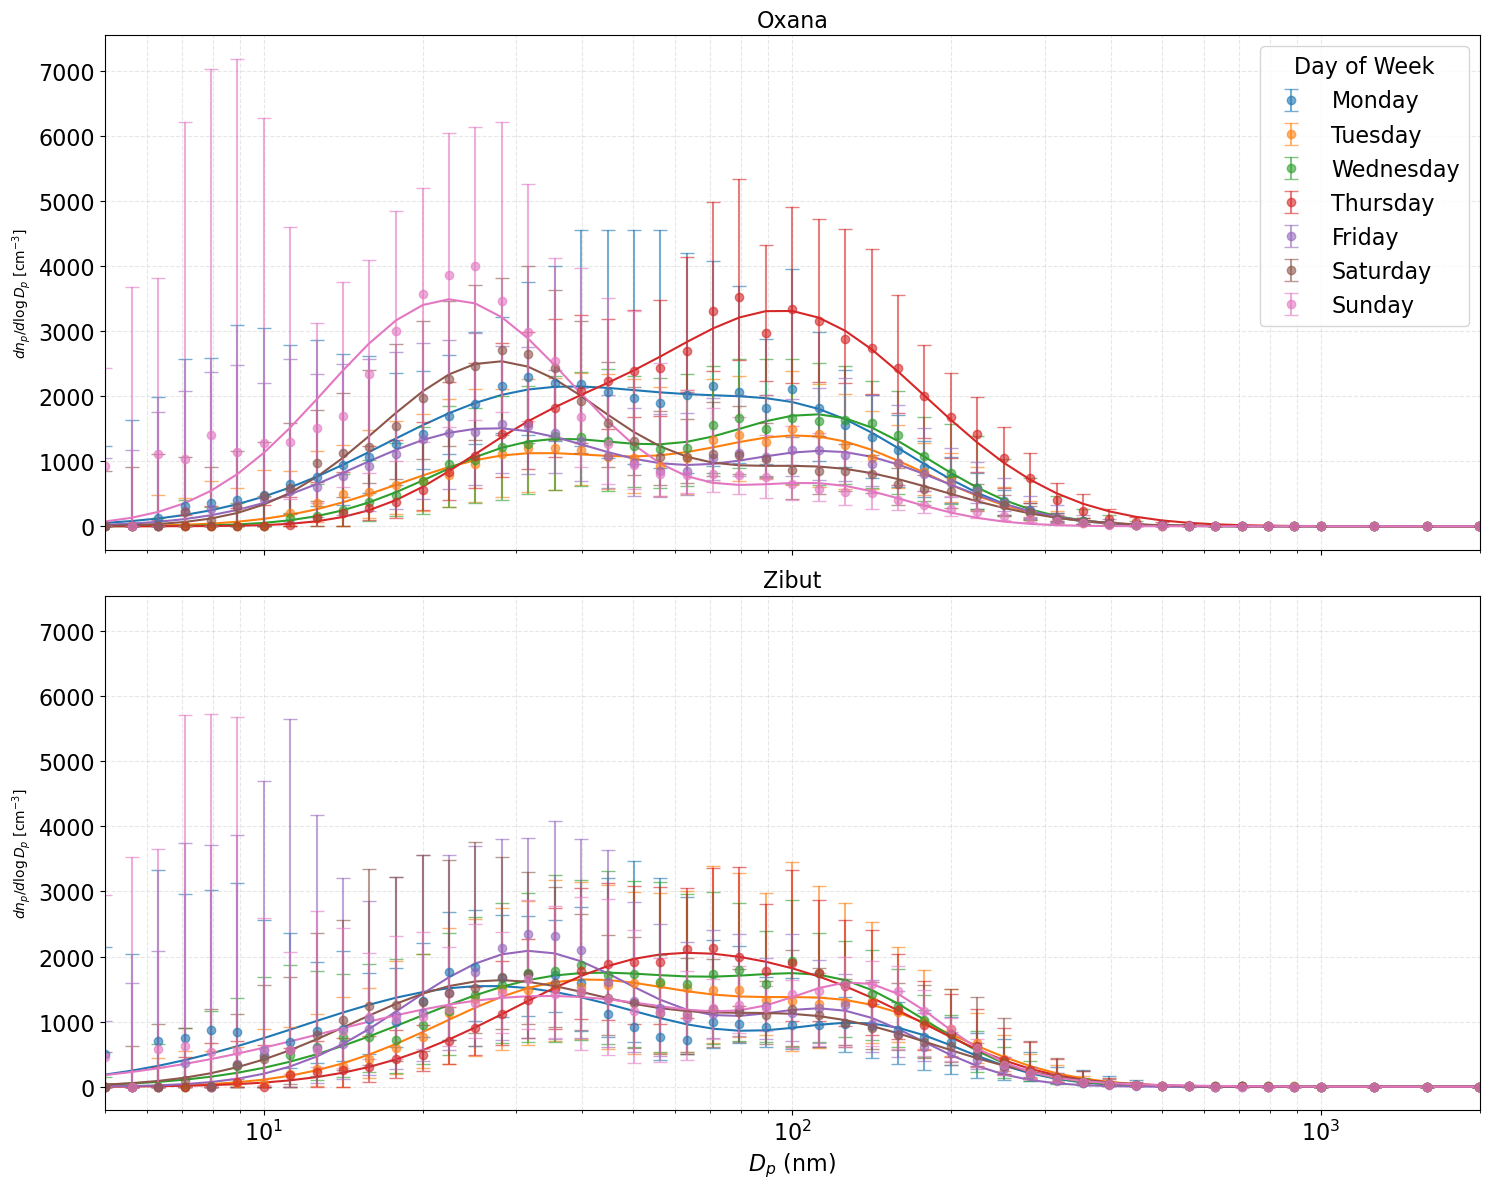

In [183]:
from scipy.optimize import curve_fit

# Define log-normal fit function
def log_norm(D, N, sigma, dg, N2, sigma2, dg2):
    output = N / ((2 * np.pi)**0.5 * np.log(sigma)) * np.exp(-(np.log(D) - np.log(dg))**2 / (2 * (np.log(sigma))**2))
    output += N2 / ((2 * np.pi)**0.5 * np.log(sigma2)) * np.exp(-(np.log(D) - np.log(dg2))**2 / (2 * (np.log(sigma2))**2))
    return output

# Setup figure with 2 subplots
fig, ax = plt.subplots(2, 1, figsize=(15, 12), sharex=True, sharey=True)

# Define weekday labels and colors
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
colors = plt.cm.tab10.colors[:7]

# Plot from weekday_summary_sorted (subplot 0)
for i, day in enumerate(weekdays):
    df = weekday_summary_sorted[day]
    x = all_mid_val['value']
    y = df['Median']
    yerr = [y - df['Q1'], df['Q3'] - y]

    # Error bars
    ax[0].errorbar(x, y, yerr=yerr, marker='o', linestyle='', capsize=5, alpha=0.6, color=colors[i], label=day)

    # Fit and plot log-normal
    try:
        popt, _ = curve_fit(log_norm, x, y, p0=[3.9e+03, 1.5, 36, 4.2e+03, 1.5, 130])
        ax[0].plot(x, log_norm(x, *popt), color=colors[i])
    except:
        pass

# Plot from weekday_summary_sorted_z (subplot 1)
for i, day in enumerate(weekdays):
    df = weekday_summary_sorted_z[day]
    x = all_mid_val['value']
    y = df['Median']
    yerr = [y - df['Q1'], df['Q3'] - y]

    # Error bars
    ax[1].errorbar(x, y, yerr=yerr, marker='o', linestyle='', capsize=5, alpha=0.6, color=colors[i])

    # Fit and plot log-normal
    try:
        popt, _ = curve_fit(log_norm, x, y, p0=[3.9e+03, 1.5, 36, 4.2e+03, 1.5, 130])
        ax[1].plot(x, log_norm(x, *popt), color=colors[i])
    except:
        pass

# Shared axes formatting
for a in ax:
    a.set_xscale('log')
    a.set_xlim(5, 2000)
    a.set_ylabel(r'$dn_p/d\log D_p$ [cm$^{-3}$]')
    a.tick_params(axis='both', which='major', labelsize=16)
    a.grid(True, which='both', linestyle='--', alpha=0.3)

# Titles
ax[0].set_title('Oxana', fontsize=16)
ax[1].set_title('Zibut', fontsize=16)
ax[1].set_xlabel(r'$D_p$ (nm)', fontsize=16)

# ✅ Single legend inside top subplot
ax[0].legend(
    title='Day of Week',
    loc='upper right',
    fontsize=16,
    title_fontsize='16',
    frameon=True
)

# Final layout
plt.tight_layout()
plt.show()


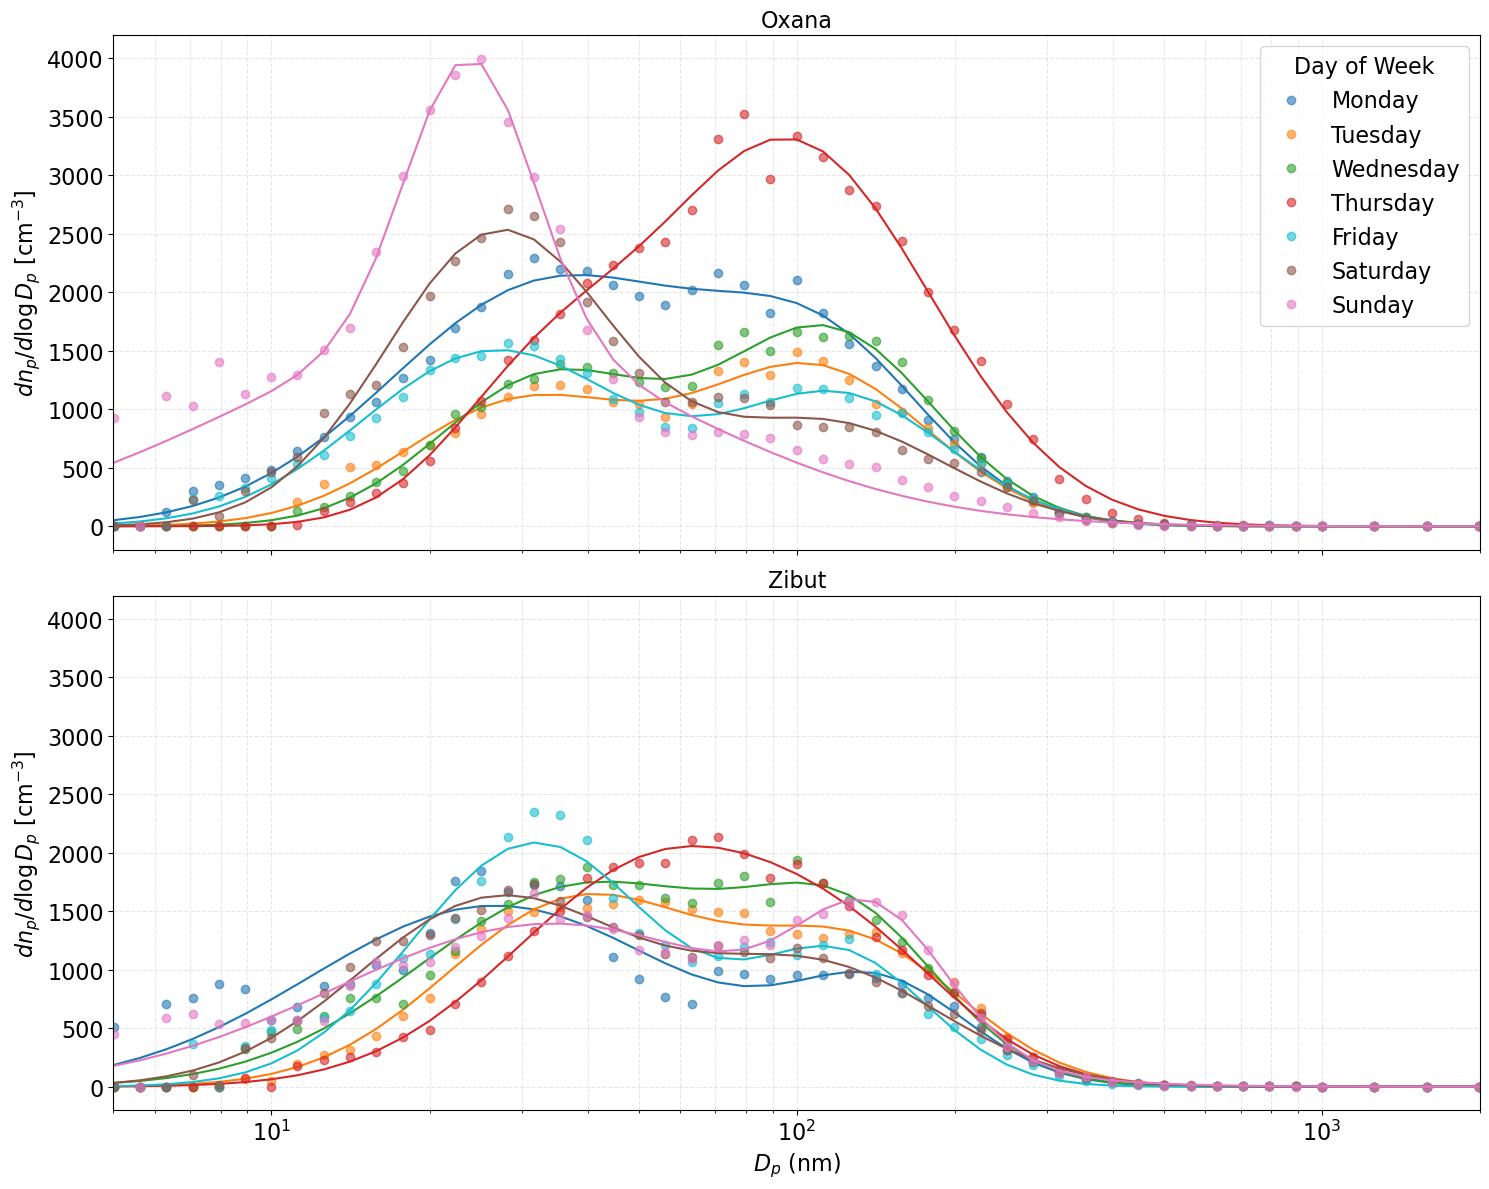

In [234]:
# Define 2-mode log-normal function
def log_norm(D, N, sigma, dg, N2, sigma2, dg2):
    output = N / ((2 * np.pi)**0.5 * np.log(sigma)) * np.exp(-(np.log(D) - np.log(dg))**2 / (2 * (np.log(sigma))**2))
    output += N2 / ((2 * np.pi)**0.5 * np.log(sigma2)) * np.exp(-(np.log(D) - np.log(dg2))**2 / (2 * (np.log(sigma2))**2))
    return output

# Plot setup
fig, ax = plt.subplots(2, 1, figsize=(15, 12), sharex=True, sharey=True)

weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#17becf", "#8c564b", "#e377c2"
]

# --- Subplot 0: Oxana ---
for i, day in enumerate(weekdays):
    df = weekday_summary_sorted[day]
    x = all_mid_val['value']
    y = df['Median']

    ax[0].plot(x, y, marker='o', linestyle='', alpha=0.6, color=colors[i], label=day)

    try:
        if day == 'Tuesday':
            p0 = [3.9e+03, 1.5, 36, 4.2e+03, 1.5, 130]
        else:
            N_guess = max(y)
            dg_guess = x[np.argmax(y)]
            sigma_guess = 1.5
            N2_guess = N_guess / 2
            dg2_guess = dg_guess * 2
            sigma2_guess = sigma_guess
            p0 = [N_guess, sigma_guess, dg_guess, N2_guess, sigma2_guess, dg2_guess]

        popt, _ = curve_fit(log_norm, x, y, p0=p0, maxfev=10000)
        ax[0].plot(x, log_norm(x, *popt), color=colors[i])
    except Exception as e:
        print(f"Fit failed for {day} (Oxana): {e}")

# --- Subplot 1: Zibut ---
for i, day in enumerate(weekdays):
    df = weekday_summary_sorted_z[day]
    x = all_mid_val['value']
    y = df['Median']

    ax[1].plot(x, y, marker='o', linestyle='', alpha=0.6, color=colors[i])

    try:
        if day == 'Wednesday':
            p0 = [3.9e+03, 1.5, 20, 4.2e+03, 1.5, 130]
        else:
            N_guess = max(y)
            dg_guess = x[np.argmax(y)]
            sigma_guess = 1.5
            N2_guess = N_guess / 2
            dg2_guess = dg_guess * 2
            sigma2_guess = sigma_guess
            p0 = [N_guess, sigma_guess, dg_guess, N2_guess, sigma2_guess, dg2_guess]

        popt, _ = curve_fit(log_norm, x, y, p0=p0, maxfev=10000)
        ax[1].plot(x, log_norm(x, *popt), color=colors[i])
    except Exception as e:
        print(f"Fit failed for {day} (Zibut): {e}")

# Format axes
for a in ax:
    a.set_xscale('log')
    a.set_xlim(5, 2000)
    a.set_ylabel(r'$dn_p/d\log D_p$ [cm$^{-3}$]', fontsize=16)
    a.tick_params(axis='both', which='major', labelsize=16)
    a.grid(True, which='both', linestyle='--', alpha=0.3)

# Titles & labels
ax[0].set_title('Oxana', fontsize=16)
ax[1].set_title('Zibut', fontsize=16)
ax[1].set_xlabel(r'$D_p$ (nm)', fontsize=16)

# Legend
ax[0].legend(
    title='Day of Week',
    loc='upper right',
    fontsize=16,
    title_fontsize='16',
    frameon=True
)

plt.tight_layout()
plt.show()


In [226]:
# Define 2-mode log-normal function
def log_norm(D, N, sigma, dg, N2, sigma2, dg2):
    output = N / ((2 * np.pi)**0.5 * np.log(sigma)) * np.exp(-(np.log(D) - np.log(dg))**2 / (2 * (np.log(sigma))**2))
    output += N2 / ((2 * np.pi)**0.5 * np.log(sigma2)) * np.exp(-(np.log(D) - np.log(dg2))**2 / (2 * (np.log(sigma2))**2))
    return output

# Store fit results
fit_params_oxana = []
fit_params_zibut = []

# Fit function without bounds
def fit_log_normal(x, y, day=None):
    try:
        if day == 'Tuesday':
            p0 = [3.9e+03, 1.5, 36, 4.2e+03, 1.5, 130]
        else:
            N_guess = max(y)
            dg_guess = x[np.argmax(y)]
            sigma_guess = 1.5
            N2_guess = N_guess / 2
            dg2_guess = dg_guess * 2
            sigma2_guess = sigma_guess
            p0 = [N_guess, sigma_guess, dg_guess, N2_guess, sigma2_guess, dg2_guess]
        popt, _ = curve_fit(log_norm, x, y, p0=p0, maxfev=10000)
        return list(popt)
    except:
        return [np.nan] * 6

# Fit Oxana
for day in weekdays:
    df = weekday_summary_sorted[day]
    x = all_mid_val['value']
    y = df['Median']
    popt = fit_log_normal(x, y, day)
    fit_params_oxana.append([day] + popt)

# Fit Zibut
for day in weekdays:
    df = weekday_summary_sorted_z[day]
    x = all_mid_val['value']
    y = df['Median']
    popt = fit_log_normal(x, y)
    fit_params_zibut.append([day] + popt)

# Build DataFrames
columns = ['Day', 'N1', 'σ1', 'dg1', 'N2', 'σ2', 'dg2']
oxana_fit_df = pd.DataFrame(fit_params_oxana, columns=columns)
zibut_fit_df = pd.DataFrame(fit_params_zibut, columns=columns)

# Display
print("Oxana log-normal fit parameters:")
display(oxana_fit_df)

print("\nZibut log-normal fit parameters:")
display(zibut_fit_df)



Oxana log-normal fit parameters:


,Day,N1,σ1,dg1,N2,σ2,dg2
0,Monday,3715.549698,2.034704,34.535262,1493.155235,1.595421,113.868028
1,Tuesday,1390.296775,1.686759,30.224156,1674.368146,1.649073,108.326364
2,Wednesday,1537.082023,1.618120,33.819822,1953.021883,1.597516,114.218849
3,Thursday,991.632404,1.492670,32.222482,5057.804578,1.845421,96.588947
4,Friday,2182.768415,1.786977,26.718066,1320.174396,1.613602,120.693798
5,Saturday,3150.942600,1.648097,27.312864,1137.876693,1.683174,114.737890
6,Sunday,1729.856699,1.322652,23.837880,3995.718974,2.826755,22.386550



Zibut log-normal fit parameters:


,Day,N1,σ1,dg1,N2,σ2,dg2
0,Monday,3153.829201,2.253068,26.670858,763.601312,1.472991,145.525954
1,Tuesday,2371.390384,1.801213,39.081310,1314.542460,1.597530,133.193327
2,Wednesday,4316.824487,2.520633,59.749520,133.924733,1.209623,30.065250
3,Thursday,3315.579805,1.952970,57.772931,605.015258,1.540499,141.130521
4,Friday,2793.743608,1.706685,31.811658,1067.751281,1.474287,121.205528
5,Saturday,2411.129157,1.823946,26.759913,1360.262727,1.727641,110.740999
6,Sunday,3317.266173,2.582311,34.305640,903.018210,1.378779,140.665659


In [221]:
'''# Define log-normal fit function
def log_norm(D, N, sigma, dg, N2, sigma2, dg2):
    output = N / ((2 * np.pi)**0.5 * np.log(sigma)) * np.exp(-(np.log(D) - np.log(dg))**2 / (2 * (np.log(sigma))**2))
    output += N2 / ((2 * np.pi)**0.5 * np.log(sigma2)) * np.exp(-(np.log(D) - np.log(dg2))**2 / (2 * (np.log(sigma2))**2))
    return output

# Setup figure with 2 subplots
fig, ax = plt.subplots(2, 1, figsize=(15, 12), sharex=True, sharey=True)

# Define weekday labels and colors
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
colors = plt.cm.tab10.colors[:7]

# Plot from weekday_summary_sorted (subplot 0)
for i, day in enumerate(weekdays):
    df = weekday_summary_sorted[day]
    x = all_mid_val['value']
    y = df['Median']

    # Just markers (no error bars)
    ax[0].plot(x, y, marker='o', linestyle='', alpha=0.6, color=colors[i], label=day)

    # Fit and plot log-normal
    try:
        popt, _ = curve_fit(log_norm, x, y, p0=[3.9e+03, 1.5, 36, 4.2e+03, 1.5, 130])
        ax[0].plot(x, log_norm(x, *popt), color=colors[i])
    except:
        pass

# Plot from weekday_summary_sorted_z (subplot 1)
for i, day in enumerate(weekdays):
    df = weekday_summary_sorted_z[day]
    x = all_mid_val['value']
    y = df['Median']

    # Just markers (no error bars)
    ax[1].plot(x, y, marker='o', linestyle='', alpha=0.6, color=colors[i])

    # Fit and plot log-normal
    try:
        popt, _ = curve_fit(log_norm, x, y, p0=[3.9e+03, 1.5, 36, 4.2e+03, 1.5, 130])
        ax[1].plot(x, log_norm(x, *popt), color=colors[i])
    except:
        pass

# Shared axes formatting
for a in ax:
    a.set_xscale('log')
    a.set_xlim(5, 2000)
    a.set_ylabel(r'$dn_p/d\log D_p$ [cm$^{-3}$]')
    a.tick_params(axis='both', which='major', labelsize=16)
    a.grid(True, which='both', linestyle='--', alpha=0.3)

# Titles
ax[0].set_title('Oxana', fontsize=16)
ax[1].set_title('Zibut', fontsize=16)
ax[1].set_xlabel(r'$D_p$ (nm)', fontsize=16)

# ✅ Single legend inside top subplot
ax[0].legend(
    title='Day of Week',
    loc='upper right',
    fontsize=16,
    title_fontsize='16',
    frameon=True
)

# Final layout
plt.tight_layout()
plt.show()'''


"# Define log-normal fit function\ndef log_norm(D, N, sigma, dg, N2, sigma2, dg2):\n    output = N / ((2 * np.pi)**0.5 * np.log(sigma)) * np.exp(-(np.log(D) - np.log(dg))**2 / (2 * (np.log(sigma))**2))\n    output += N2 / ((2 * np.pi)**0.5 * np.log(sigma2)) * np.exp(-(np.log(D) - np.log(dg2))**2 / (2 * (np.log(sigma2))**2))\n    return output\n\n# Setup figure with 2 subplots\nfig, ax = plt.subplots(2, 1, figsize=(15, 12), sharex=True, sharey=True)\n\n# Define weekday labels and colors\nweekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']\ncolors = plt.cm.tab10.colors[:7]\n\n# Plot from weekday_summary_sorted (subplot 0)\nfor i, day in enumerate(weekdays):\n    df = weekday_summary_sorted[day]\n    x = all_mid_val['value']\n    y = df['Median']\n\n    # Just markers (no error bars)\n    ax[0].plot(x, y, marker='o', linestyle='', alpha=0.6, color=colors[i], label=day)\n\n    # Fit and plot log-normal\n    try:\n        popt, _ = curve_fit(log_norm, x